### Content: data cleaning
- remove wrong coordinates (latitude or longitude less than zero, in particular some rows have values equal to -180).
- fix point_trip_id: some ID repeat themselves after some days: must modify them so that each ID is unique for each trip (different ID in different days).
- filter out data outiside the area of interest (where scooters are allowed) using alphashape.

Produce *trips_pointv3_cleaned.parquet*.

### Issue 1: filter out wrong coordinates

In [29]:
try:
  import geopandas as gpd
except ModuleNotFoundError as e:
  !pip install geopandas==0.10.1
  import geopandas as gpd

if gpd.__version__ != "0.10.1":
  !pip install -U geopandas==0.10.1
  import geopandas as gpd

try:
  import alphashape
except ModuleNotFoundError as e:
  !pip install alphashape==1.3.1
  import alphashape
if alphashape.__version__ != "1.3.1":
  !pip install -U alphashape==1.3.1
  import alphashape

     |████████████████████████████████| 1.0 MB 4.8 MB/s 
     |████████████████████████████████| 645 kB 32.9 MB/s 


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import alphashape
from shapely.geometry import Point, Polygon

In [2]:
data = pd.read_parquet('trips_pointv3.parquet')
data

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,None
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,None
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,None
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,None
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,None
...,...,...,...,...,...,...,...,...
999995,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:41+00:00,46.079951,11.117475,3,None
999996,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:51+00:00,46.079677,11.117734,4,None
999997,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:01+00:00,46.079403,11.117844,5,None
999998,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:11+00:00,46.079176,11.117913,6,None


In [3]:
data.point_reliability.unique() # all None

array([None], dtype=object)

In [4]:
data[data.point_latitude <= 0]

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability
475591,VENTO,WIND,900475a38fe9,2021-10-26 15:19:32+00:00,-180.000000,-180.000000,8,None
555862,VENTO,WIND,5e77bb1ac8cc,2021-06-08 19:56:41+00:00,-180.000000,-180.000000,25,None
888941,VENTO,WIND,8881fc856210,2021-05-04 16:06:22+00:00,-180.000000,-180.000000,39,None


In [5]:
data[data.point_longitude <= 0]

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability
475591,VENTO,WIND,900475a38fe9,2021-10-26 15:19:32+00:00,-180.000000,-180.000000,8,None
555862,VENTO,WIND,5e77bb1ac8cc,2021-06-08 19:56:41+00:00,-180.000000,-180.000000,25,None
888941,VENTO,WIND,8881fc856210,2021-05-04 16:06:22+00:00,-180.000000,-180.000000,39,None


In [6]:
data = data[data.point_longitude >= 0]
data = data[data.point_latitude >= 0]
data

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,None
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,None
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,None
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,None
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,None
...,...,...,...,...,...,...,...,...
999995,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:41+00:00,46.079951,11.117475,3,None
999996,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:51+00:00,46.079677,11.117734,4,None
999997,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:01+00:00,46.079403,11.117844,5,None
999998,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:11+00:00,46.079176,11.117913,6,None


In [7]:
data = data.reset_index()

### Issue 2: ID repeat themselves in different days

In [8]:
data[data.point_trip_id =='00000001-0000-1000-9ec1-5b7d6a617b60'] ## how is it that the same ID appears in different days? does it mean it's the same person?

,index,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability
80744,80744,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2020-12-03 14:14:57+00:00,46.060532,11.115307,0,None
80974,80974,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2020-12-03 14:44:40+00:00,46.060551,11.115251,1,None
93023,93023,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-02-16 15:05:28+00:00,46.071957,11.120046,0,None
97117,97117,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-02-16 15:15:17+00:00,46.060024,11.133364,1,None
101247,101247,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-03-20 20:52:02+00:00,46.061253,11.126844,1,None
102618,102618,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-03-20 20:14:08+00:00,46.061020,11.124775,0,None
112022,112022,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-05-04 14:19:43+00:00,46.073273,11.126663,0,None
116615,116615,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-05-04 14:24:13+00:00,46.082153,11.122440,1,None
119678,119678,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-05-19 17:48:56+00:00,46.083977,11.119506,0,None
119679,119679,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2021-05-19 17:55:59+00:00,46.069721,11.121650,1,None


In [9]:
# add date column
lst_gg = []
for gg in range(len(data.point_timestamp)):
  lst_gg.append(data.point_timestamp[gg].date())
data['date'] = lst_gg

In [10]:
# create a unique id as concatenation of point_trip_id and date
id=[]
for r in range(len(data)):
  id.append(str(data.point_trip_id[r])+'_'+str(data.date[r]))
data['unique_id'] = id

In [11]:
data.head()

,index,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability,date,unique_id
0,0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,None,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07
1,1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,None,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07
2,2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,None,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07
3,3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,None,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07
4,4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,None,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07


In [12]:
data[data.unique_id == '00000001-0000-1000-9ec1-5b7d6a617b60_2020-12-03']

,index,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability,date,unique_id
80744,80744,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2020-12-03 14:14:57+00:00,46.060532,11.115307,0,None,2020-12-03,00000001-0000-1000-9ec1-5b7d6a617b60_2020-12-03
80974,80974,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2020-12-03 14:44:40+00:00,46.060551,11.115251,1,None,2020-12-03,00000001-0000-1000-9ec1-5b7d6a617b60_2020-12-03


In [13]:
data = data.drop(['index', 'point_reliability'], axis=1) # drop also "point_reliability" because filled with None only
data.head(2)

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,date,unique_id
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07


### Issue 3: filter out data outside area where e-scooters are allowed

In [14]:
data = gpd.GeoDataFrame(data, crs='EPSG:4326', geometry=gpd.points_from_xy(data.point_longitude, data.point_latitude))

In [15]:
data.head()

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,date,unique_id,geometry
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12041 46.05297)
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12047 46.05295)
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12081 46.05291)
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12112 46.05287)
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12153 46.05273)


In [16]:
# caricamento aree dove sono concessi gli spostamenti
area = gpd.read_file("ambito_esercizio_monopattini.shp")

In [17]:
area

,ogc_fid,area,perimetro,fumetto,descrizion,geometry
0,69,382183.0,6483.0,Piedicastello,Piedicastello,"POLYGON ((663578.614 5104176.203, 663552.243 5..."
1,76,397561.0,5947.0,San Lazzaro - Lamar,San Lazzaro - Lamar,"POLYGON ((663046.736 5111202.450, 663140.429 5..."
2,90,10687849.0,29010.0,Trento,Trento,"POLYGON ((664269.286 5105158.048, 664272.050 5..."
3,84,941531.0,5720.0,Gardolo,Gardolo,"POLYGON ((662829.584 5108862.129, 662833.817 5..."
4,82,161847.0,3360.0,Vela,Vela,"POLYGON ((662639.688 5104893.315, 662634.213 5..."
5,83,824374.0,5758.0,Gardolo,Gardolo,"POLYGON ((662154.871 5108224.534, 662188.913 5..."
6,86,364694.0,3610.0,Roncafort,Roncafort,"POLYGON ((662740.584 5106685.497, 662729.968 5..."
7,104,2174212.0,7929.0,Spini,Spini,"POLYGON ((661403.971 5109069.894, 661407.294 5..."


In [18]:
# !pip install fiona
import fiona
file = fiona.open("ambito_esercizio_monopattini.shp")
spatialRef = file.crs
spatialRef # get reference system

{'init': 'epsg:25832'}

In [19]:
points = []
for idx, row in area.iterrows():
  points= points + (list(area.geometry[idx].exterior.coords))
points = np.array(points)

In [20]:
points

array([[ 663578.61363114, 5104176.20270742],
       [ 663552.24315535, 5104082.1862285 ],
       [ 663526.44595077, 5104041.48397239],
       ...,
       [ 661406.93824153, 5109049.71587002],
       [ 661403.02137926, 5109057.78698015],
       [ 661403.97092163, 5109069.89364535]])

In [21]:
alpha_shape = alphashape.alphashape(points, 0.0001)

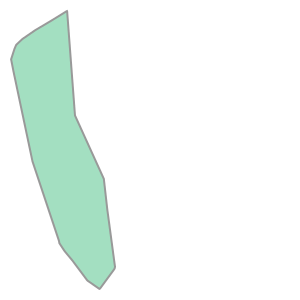

In [22]:
alpha_shape

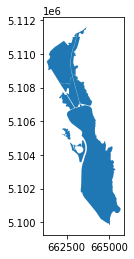

In [23]:
area.plot()

In [24]:
# change CRS

import pyproj
from shapely.ops import transform

project = pyproj.Transformer.from_proj(
    pyproj.Proj(init='epsg:25832'), # source coordinate system
    pyproj.Proj(init='epsg:4326')) # destination coordinate system


g2 = transform(project.transform, alpha_shape)  # apply projection to alpha shape polygon

/usr/local/lib/python3.7/dist-packages/pyproj/crs/crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/usr/local/lib/python3.7/dist-packages/pyproj/crs/crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [25]:
import folium
map = folium.Map((46.066667,11.133333), zoom_start=12)
folium.GeoJson(g2).add_to(map)
map

In [26]:
type(g2)

shapely.geometry.polygon.Polygon

In [27]:
data["is_within"] = data.apply(lambda row: g2.intersects(Point(row["point_longitude"], row["point_latitude"])), axis = 1)

In [28]:
data.is_within.unique()

array([ True, False])

In [29]:
print('False:', len(data[data.is_within==False]), 'True:', len(data[data.is_within==True]))

False: 1188 True: 998809


In [30]:
import matplotlib.pyplot as plt

dataFalse = data[data.is_within==False]

gdp = gpd.GeoDataFrame(
    dataFalse,
    crs='EPSG:4326',
    geometry=gpd.points_from_xy(dataFalse.point_longitude, dataFalse.point_latitude))

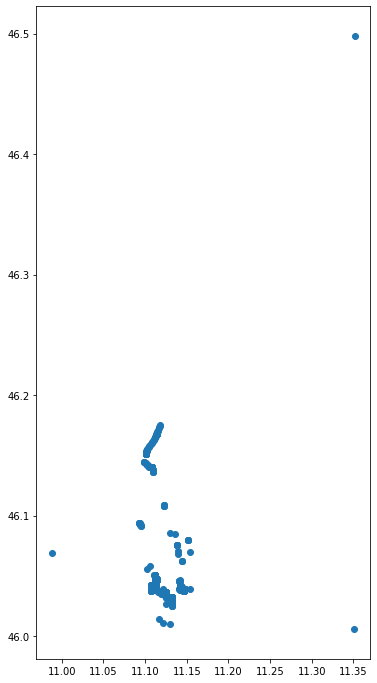

In [31]:
gdp.plot(figsize=(12,12))
plt.show()

In [32]:
data = data[data.is_within == True]

In [36]:
data = data.drop(['is_within'], axis=1)

In [37]:
data.head()

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,date,unique_id,geometry
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12041 46.05297)
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12047 46.05295)
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12081 46.05291)
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12112 46.05287)
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12153 46.05273)


Save cleaned file.

In [38]:
import os
import sys 
from google.colab import drive 
import glob

path = "/content/drive" 
drive.mount(path, force_remount=True)  
data_path = "drive/MyDrive/Colab Notebooks/escooter_TN" 

myfiles = glob.glob(os.path.join(data_path, '*')) 
print(myfiles)

Mounted at /content/drive
['drive/MyDrive/Colab Notebooks/escooter_TN/trento.pbf', 'drive/MyDrive/Colab Notebooks/escooter_TN/dataviz_spostamenti.html', 'drive/MyDrive/Colab Notebooks/escooter_TN/dataviz_spostamenti_monopattini.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/traiettorie_con_MovingPandas.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/check_datasets-delete.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/traiettorie.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/trips_pointv3_cleaned.parquet', 'drive/MyDrive/Colab Notebooks/escooter_TN/ExploreTrips.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/0_clean_data.ipynb']


In [39]:
data.to_parquet(data_path+'/trips_pointv3_cleaned.parquet')

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: UserWarning: this is an initial implementation of Parquet/Feather file support and associated metadata.  This is tracking version 0.1.0 of the metadata specification at https://github.com/geopandas/geo-arrow-spec

This metadata specification does not yet make stability promises.  We do not yet recommend using this in a production setting unless you are able to rewrite your Parquet/Feather files.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', message='.*initial implementation of Parquet.*')
  """Entry point for launching an IPython kernel.
